In [7]:
# Step 1: Import necessary libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Ensure the TensorFlow version is 2.x
print(f'TensorFlow version: {tf.__version__}')


Matplotlib is building the font cache; this may take a moment.


TensorFlow version: 2.17.0


In [8]:
# Step 2: Load and preprocess data
def load_data(file_path):
    with open(file_path, 'r') as file:
        text = file.read()
    sentences = text.split('. ')
    return sentences

# Example usage
sentences = load_data('text.txt')
print(f'First 5 sentences: {sentences[:5]}')


First 5 sentences: ['\ufeffOne morning, when Gregor Samsa woke from troubled dreams, he found\nhimself transformed in his bed into a horrible vermin', ' He lay on\nhis armour-like back, and if he lifted his head a little he could\nsee his brown belly, slightly domed and divided by arches into stiff\nsections', ' The bedding was hardly able to cover it and seemed ready\nto slide off any moment', ' His many legs, pitifully thin compared\nwith the size of the rest of him, waved about helplessly as he\nlooked.\n\n"What\'s happened to me?" he thought', " It wasn't a dream"]


In [22]:
# Step 3: Preprocess the sentences
def preprocess_data(sentences):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(sentences)
    sequences = tokenizer.texts_to_sequences(sentences)
    vocab_size = len(tokenizer.word_index) + 1
    return sequences, tokenizer, vocab_size

# Example usage
sequences, tokenizer, vocab_size = preprocess_data(sentences)
print(f'Sequences (first 5): {sequences[:5]}')
print(f'Vocabulary size: {vocab_size}')
print(f'Word index (first 10): {dict(list(tokenizer.word_index.items())[:10])}')


Sequences (first 5): [[220, 117, 29, 12, 118, 221, 30, 222, 223, 2, 119, 31, 224, 11, 5, 42, 61, 6, 225, 226], [2, 80, 32, 5, 227, 62, 36, 4, 26, 2, 228, 5, 81, 6, 43, 2, 37, 82, 5, 229, 120, 230, 231, 4, 232, 44, 233, 61, 234, 235], [1, 236, 7, 121, 237, 3, 238, 10, 4, 122, 123, 3, 239, 50, 83, 240], [5, 124, 63, 241, 242, 243, 14, 1, 244, 8, 1, 245, 8, 38, 246, 39, 247, 20, 2, 125, 84, 248, 3, 126, 2, 45], [10, 249, 6, 250]]
Vocabulary size: 606
Word index (first 10): {'the': 1, 'he': 2, 'to': 3, 'and': 4, 'his': 5, 'a': 6, 'was': 7, 'of': 8, 'that': 9, 'it': 10}


In [17]:
# Step 4: Prepare data for training
def prepare_data_for_training(sequences, vocab_size):
    xs = []
    ys = []
    
    for seq in sequences:
        for i in range(1, len(seq)):
            xs.append(seq[i-1])
            ys.append(seq[i])
    
    xs = np.array(xs)
    ys = tf.keras.utils.to_categorical(ys, num_classes=vocab_size)
    
    return xs, ys

# Example usage
data, labels = prepare_data_for_training(sequences, vocab_size)
print(f'Shape of data: {data.shape}')
print(f'Shape of labels: {labels.shape}')


Shape of data: (1583, 606)
Shape of labels: (1583, 606)


In [18]:
# Step 5: Create and compile the model
def create_model(vocab_size):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=100),
        LSTM(100, activation='relu', return_sequences=True),
        LSTM(100, activation='relu'),
        Dense(vocab_size, activation='softmax')
    ])
    
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(0.01),
        metrics=['accuracy']
    )
    
    return model

# Example usage
model = create_model(vocab_size)
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 605ms/step - accuracy: 0.0021 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 611ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 631ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 633ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 629ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 626ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 627ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 630ms/step - accuracy: 0.0000e+00 - loss: nan - val_accu

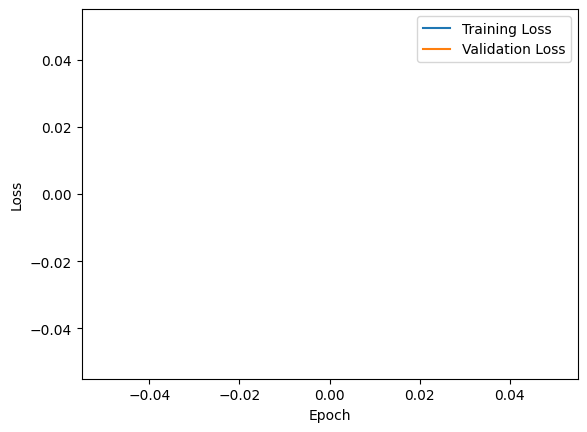

In [19]:
# Step 6: Train the model with progress visualization
def plot_training_history(history):
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def train_model_with_progress(model, data, labels, epochs):
    history = model.fit(
        data, labels,
        epochs=epochs,
        batch_size=16,
        validation_split=0.2
    )
    return history

# Example usage
history = train_model_with_progress(model, data, labels, epochs=5)
plot_training_history(history)


In [27]:
# Step 7: Predict the next word
def predict_next_word(model, tokenizer, input_text):
    sequence = tokenizer.texts_to_sequences([input_text.split()])[-1]
    sequence = pad_sequences([sequence], maxlen=1)
    prediction = model.predict(sequence)
    print(f'prediction: {prediction}')
    predicted_word_index = np.argmax(prediction)
    print(f'predicted_word_index: {predicted_word_index}')
    
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            return word

# Example usage
input_text = "and"
next_word = predict_next_word(model, tokenizer, input_text)
print(f'Next word prediction: {next_word}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
prediction: [[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan 